In [5]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.patches as patches
import json, random

In [6]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [7]:
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [8]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Mar 24 11:44:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)

cuda:0


# Split the dataset into a training set and a validation set at slices level

In [10]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/MPC2026-shortcourse'
!ls $root_folder

Mounted at /content/drive
cls_train.pkl			  dataset_for_detection.zip
cls_val.pkl			  meta_classification.txt
code011_detection_dataPrep.ipynb  meta_detection.pkl
dataset_for_classification	  slides
dataset_for_classification.zip	  test-image.jpg
dataset_for_detection_backup.zip


In [14]:
dataset_folder = os.path.join(root_folder, 'dataset_for_detection')

if not os.path.isdir(dataset_folder):
    zip_file = os.path.join(root_folder, 'dataset_for_detection.zip')
    !echo $zip_file
    !echo $dest_folder
    !unzip $zip_file -d $root_folder

/content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection.zip

Archive:  /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection.zip
   creating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/
   creating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/51136x_40000y/
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/51136x_40000y/51136x_40000y_full_annotation.pkl  
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/51136x_40000y/2z.jpg  
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/51136x_40000y/3z.jpg  
   creating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/40000x_53520y/
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/40000x_53520y/4z.jpg  
  inflating: /content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/40000x_53520y/40000x_53520y_full_annotation.pkl  
   creating: /content/drive

In [15]:
train_portion = 0.8 # using 80% data for training
valid_portion = 1-train_portion # using the rest 20% data for validation

train_sliceList = []
valid_sliceList = []

sliceslist = os.listdir(dataset_folder)
permutedInds = np.random.permutation(len(sliceslist))

trainNum = round(len(sliceslist)*train_portion)
validNum = len(sliceslist) - trainNum

for i in range(len(permutedInds)):
    curIdx = permutedInds[i]
    cur_slice = sliceslist[curIdx]
    if i<trainNum:
        train_sliceList += [os.path.join(dataset_folder, cur_slice)]
    else:
        valid_sliceList += [os.path.join(dataset_folder, cur_slice)]
    # print('processing of ' + cur_slice +' is finished')

In [16]:
filename_pickle = 'det_trainval_splits.pkl'
with open(filename_pickle, 'wb') as file:
    pickle.dump({'train_sliceList':train_sliceList,
                 'valid_sliceList':valid_sliceList}, file)

# Prepare images and masks for train and validation sets

In [17]:
with open(filename_pickle, 'rb') as file:
    tmp_info = pickle.load(file)

train_sliceList = tmp_info['train_sliceList']
valid_sliceList = tmp_info['valid_sliceList']

In [18]:
len(train_sliceList), len(valid_sliceList)

(133, 33)

In [19]:
train_imgList = []
train_maskList = []
valid_imgList = []
valid_maskList = []

In [20]:
for i in range(len(train_sliceList)):
    cur_path = train_sliceList[i]
    cur_tile = os.path.split(cur_path)[-1]
    sliceslist = os.listdir(cur_path)
    cur_img_num = len(sliceslist)-1
    cur_annotation_file = os.path.join(cur_path, cur_tile + "_full_annotation.pkl")
    with open(cur_annotation_file, 'rb') as file:
        annotInfo = pickle.load(file)
    for elm in sliceslist:
        if '.jpg' in elm:
            train_imgList += [os.path.join(cur_path, elm)]
            train_maskList += [annotInfo]

In [21]:
len(train_imgList), len(train_maskList)

(179, 179)

In [22]:
for i in range(len(valid_sliceList)):
    cur_path = valid_sliceList[i]
    cur_tile = os.path.split(cur_path)[-1]
    sliceslist = os.listdir(cur_path)
    cur_img_num = len(sliceslist)-1
    cur_annotation_file = os.path.join(cur_path, cur_tile + "_full_annotation.pkl")
    with open(cur_annotation_file, 'rb') as file:
        annotInfo = pickle.load(file)
    for elm in sliceslist:
        if '.jpg' in elm:
            valid_imgList += [os.path.join(cur_path, elm)]
            valid_maskList += [annotInfo]

In [23]:
len(valid_imgList), len(valid_maskList)

(42, 42)

In [24]:
# save this split for training and evaluation the model we will develop later
filename = './meta_detection.pkl'
with open(filename, 'wb') as file:
    pickle.dump({'train_imgList':train_imgList,
                 'train_maskList':train_maskList,
                 'valid_imgList':valid_imgList,
                 'valid_maskList':valid_maskList}, file)

In [25]:
# take this as an example
valid_imgList[1], valid_maskList[1]

('/content/drive/MyDrive/MPC2026-shortcourse/dataset_for_detection/51136x_52480y/4z.jpg',
 [['u_m', '', '', 206, 854, 50], ['cec', '', '', 1216, 473, 30]])

(1040, 1392, 3)


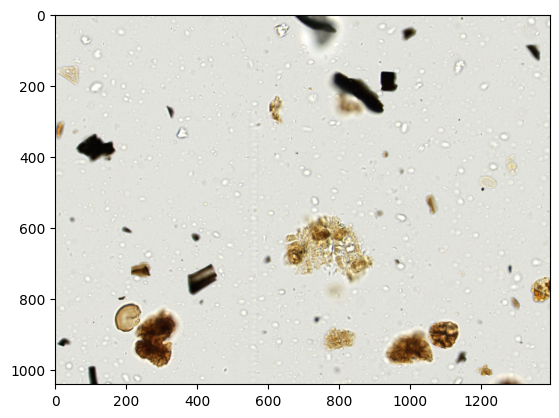

In [26]:
image = skimage.io.imread(os.path.join(valid_imgList[1]))
print(image.shape)
plt.imshow(image)

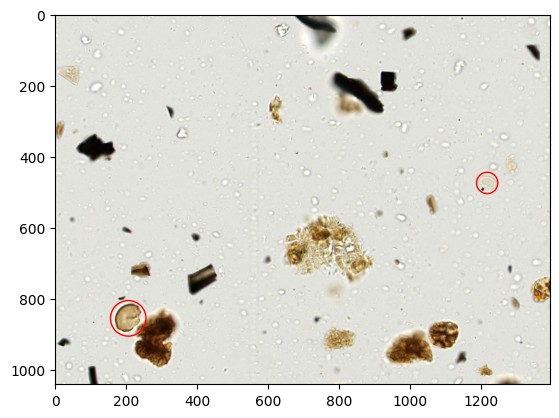

In [27]:
# Create a figure and axes
fig, ax = plt.subplots() #
plt.imshow(image)

for elm in valid_maskList[1]:
    # Create a Circle patch object: center (x, y) and radius
    center_x = elm[3]
    center_y = elm[4]
    radius = elm[5]
    circle = patches.Circle((center_x, center_y), radius, color='r', fill=False) #
    ax.add_patch(circle) # Add the patch to the axes

plt.show()


# develop a helper function to create ground-truth for training deep learning models of pollen segmentation/detection.
The ground-truth is a distance transform map, measuring the distance from a pixel (within a pollen grain) to this grains circular boundary

In [28]:
# create a map of distance transform, measuring the distance from pollen gain center to its circular boundary

mask = image[:,:,0]*0
distTransformList = []

distTransformList = []
for elm in valid_maskList[1]:
    # Create a Circle patch object: center (x, y) and radius
    center_x = elm[3]
    center_y = elm[4]
    radius = elm[5]

    mask_x, mask_y = np.asarray(range(mask.shape[1])).astype(np.float32), np.asarray(range(mask.shape[0])).astype(np.float32)
    mask_x, mask_y = np.meshgrid(mask_x, mask_y)
    mask_x = float(center_x) - mask_x
    mask_y = float(center_y) - mask_y

    tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
    tmpDistTransform[tmpDistTransform<0]=0
    distTransformList += [tmpDistTransform]

distTransform = np.stack(distTransformList)
distTransform = np.max(distTransform,0)

In [29]:
distTransform = np.stack(distTransformList)
distTransform = np.max(distTransform,0)

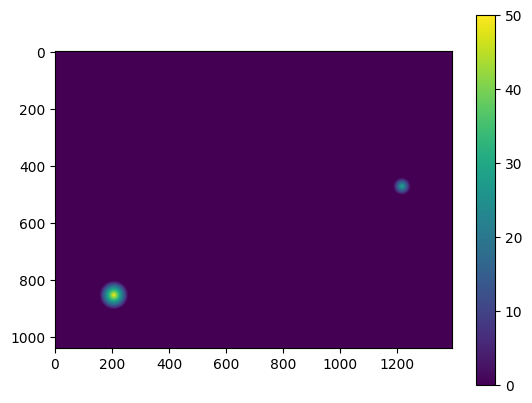

In [30]:
plt.imshow(distTransform)
plt.colorbar()

In [31]:
# let's make a function and use it later in the dataloader supporting deep learning
def makeDistanceTransformMask(maskSize, valid_maskList):
    distTransformList = []
    for elm in valid_maskList[1]:
        # Create a Circle patch object: center (x, y) and radius
        center_x = elm[3]
        center_y = elm[4]
        radius = elm[5]

        mask_x, mask_y = np.asarray(range(mask.shape[1])).astype(np.float32), np.asarray(range(mask.shape[0])).astype(np.float32)
        mask_x, mask_y = np.meshgrid(mask_x, mask_y)
        mask_x = float(center_x) - mask_x
        mask_y = float(center_y) - mask_y

        tmpDistTransform = radius-np.sqrt(mask_x*mask_x + mask_y*mask_y)
        tmpDistTransform[tmpDistTransform<0]=0
        distTransformList += [tmpDistTransform]

    distTransform = np.stack(distTransformList)
    distTransform = np.max(distTransform,0)

    return distTransform

In [32]:
DistTransformMask = makeDistanceTransformMask(image.shape[:2], valid_maskList)

print(DistTransformMask.shape, DistTransformMask.max(), DistTransformMask.min())

(1040, 1392) 50.0 0.0


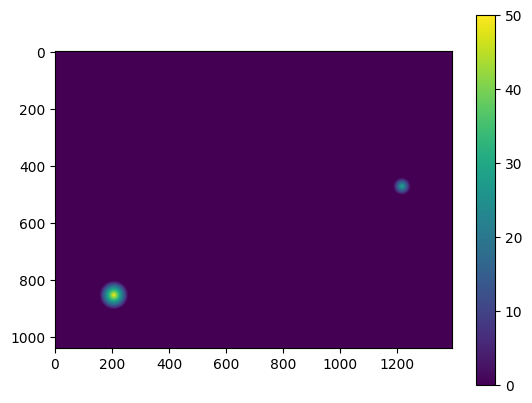

In [33]:
plt.imshow(DistTransformMask)
plt.colorbar()